# Property Ledger — Exploratory Data Analysis

EDA for `data/property_ledger.parquet`.

**Goal:** understand structure, quality, and key financial patterns before building the asset-management 

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# Load from parquet (source of truth; a CSV copy also exists alongside)
DATA = Path("..") / "data" / "property_ledger.parquet"
df = pd.read_parquet(DATA)
print("Shape:", df.shape)
df.head()

Shape: (3924, 12)


,entity_name,property_name,tenant_name,ledger_type,ledger_group,ledger_category,ledger_code,ledger_description,month,quarter,year,profit
0,PropCo,None,None,expenses,general_expenses,bank_charges,4650,Bankkosten | Bank charges,2025-M01,2025-Q1,2025,-24.0
1,PropCo,None,None,expenses,general_expenses,financial_expenses,4650,Bankkosten | Bank charges,2025-M01,2025-Q1,2025,-24.0
2,PropCo,None,None,expenses,management_fees,directors_fee,4801,Director's Fee,2025-M02,2025-Q1,2025,-500.0
3,PropCo,Building 180,None,expenses,general_expenses,other_general_expenses,4898,Overige algemene kosten | Other general costs,2024-M12,2024-Q4,2024,-225.0
4,PropCo,None,None,expenses,general_expenses,bank_charges,4650,Bankkosten | Bank charges,2025-M01,2025-Q1,2025,-24.0


## 2. Structure & dtypes

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3924 entries, 0 to 3923
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   entity_name         3924 non-null   object 
 1   property_name       3343 non-null   object 
 2   tenant_name         3165 non-null   object 
 3   ledger_type         3924 non-null   object 
 4   ledger_group        3924 non-null   object 
 5   ledger_category     3924 non-null   object 
 6   ledger_code         3924 non-null   int32  
 7   ledger_description  3924 non-null   object 
 8   month               3924 non-null   object 
 9   quarter             3924 non-null   object 
 10  year                3924 non-null   object 
 11  profit              3924 non-null   float64
dtypes: float64(1), int32(1), object(10)
memory usage: 352.7+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
entity_name,3924,1,PropCo,3924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_name,3343,5,Building 17,1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenant_name,3165,18,Tenant 12,479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ledger_type,3924,2,revenue,3135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ledger_group,3924,5,rental_income,2932,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ledger_category,3924,29,revenue_rent_taxed,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ledger_code,3924.0,NaN,NaN,NaN,7350.181448,1299.472369,4370.0,8000.0,8000.0,8001.0,8008.0
ledger_description,3924,28,Opbrengst Huren belast Revenue Rent taxed,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,3924,15,2024-M06,804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quarter,3924,5,2024-Q2,1102,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing values

In [5]:
na = df.isna().sum().to_frame("n_missing")
na["pct"] = (na["n_missing"] / len(df) * 100).round(1)
na.sort_values("n_missing", ascending=False)

,n_missing,pct
tenant_name,759,19.3
property_name,581,14.8
entity_name,0,0.0
ledger_type,0,0.0
ledger_group,0,0.0
ledger_category,0,0.0
ledger_code,0,0.0
ledger_description,0,0.0
month,0,0.0
quarter,0,0.0


`property_name` and `tenant_name` are missing on a meaningful share of rows — these correspond to
**entity-level** lines (e.g. bank charges, director's fees) that aren't attributable to a single building
or tenant. That's expected structure, not dirty data.

## 4. Categorical cardinality

In [6]:
cat_cols = ["entity_name","property_name","tenant_name","ledger_type",
            "ledger_group","ledger_category","ledger_code","ledger_description",
            "month","quarter","year"]
for c in cat_cols:
    u = df[c].dropna().unique()
    print(f"{c:20s} {len(u):>4d} unique")

entity_name             1 unique
property_name           5 unique
tenant_name            18 unique
ledger_type             2 unique
ledger_group            5 unique
ledger_category        29 unique
ledger_code            28 unique
ledger_description     28 unique
month                  15 unique
quarter                 5 unique
year                    2 unique


In [7]:
# The ledger hierarchy: type -> group -> category
(df.groupby(["ledger_type","ledger_group"])["ledger_category"]
   .nunique()
   .rename("n_categories")
   .reset_index())

,ledger_type,ledger_group,n_categories
0,expenses,general_expenses,15
1,expenses,management_fees,5
2,expenses,taxes_and_insurances,2
3,revenue,rental_income,5
4,revenue,sales_discounts,2


## 4b. All unique values per column

List every distinct value in each column, then export a wide reference CSV to
`data/unique_values.csv` — one column per field, with that field's unique values
stacked underneath (NaN dropped, columns padded to equal length).

In [8]:
# Print all unique values for each column
for c in df.columns:
    u = sorted(df[c].dropna().unique(), key=lambda x: str(x))
    print(f"\n{c}  ({len(u)} unique)")
    print(u)


entity_name  (1 unique)
['PropCo']

property_name  (5 unique)
['Building 120', 'Building 140', 'Building 160', 'Building 17', 'Building 180']

tenant_name  (18 unique)
['Tenant 1', 'Tenant 10', 'Tenant 11', 'Tenant 12', 'Tenant 13', 'Tenant 14', 'Tenant 15', 'Tenant 16', 'Tenant 17', 'Tenant 18', 'Tenant 2', 'Tenant 3', 'Tenant 4', 'Tenant 5', 'Tenant 6', 'Tenant 7', 'Tenant 8', 'Tenant 9']

ledger_type  (2 unique)
['expenses', 'revenue']

ledger_group  (5 unique)
['general_expenses', 'management_fees', 'rental_income', 'sales_discounts', 'taxes_and_insurances']

ledger_category  (29 unique)
['accountant_costs', 'administration_costs', 'asset_management_fees', 'bank_charges', "broker's_fees", 'directors_fee', 'expense_return', 'financial_expenses', 'insurance_in_general', 'interest_mortgage', 'legal_advice', 'maintenance_owner', 'non_reclaimable_sc', 'non_reclaimable_vat', 'other_consultancy_costs', 'other_general_expenses', 'other_management_fees', 'permits_and_fees', 'proceeds_parki

In [9]:
# Build a wide table: each column header = field name, rows = its unique values
uniques = {
    c: pd.Series(sorted(df[c].dropna().unique(), key=lambda x: str(x)))
    for c in df.columns
}
unique_values_df = pd.DataFrame(uniques)  # unequal lengths auto-padded with NaN

out_path = Path("..") / "data" / "unique_values.csv"
unique_values_df.to_csv(out_path, index=False)
print(f"Wrote {out_path}  shape={unique_values_df.shape}")
unique_values_df.head(20)

Wrote ..\data\unique_values.csv  shape=(871, 12)


,entity_name,property_name,tenant_name,ledger_type,ledger_group,ledger_category,ledger_code,ledger_description,month,quarter,year,profit
0,PropCo,Building 120,Tenant 1,expenses,general_expenses,accountant_costs,4370.0,Accountantskosten | Accountant costs,2024-M01,2024-Q1,2024,-0.00
1,NaN,Building 140,Tenant 10,revenue,management_fees,administration_costs,4460.0,Administratiekosten | Administration costs,2024-M02,2024-Q2,2025,-0.01
2,NaN,Building 160,Tenant 11,NaN,rental_income,asset_management_fees,4611.0,Asset Management Fees,2024-M03,2024-Q3,NaN,-0.02
3,NaN,Building 17,Tenant 12,NaN,sales_discounts,bank_charges,4650.0,BTW-compensatie VAT compensation,2024-M04,2024-Q4,NaN,-0.03
4,NaN,Building 180,Tenant 13,NaN,taxes_and_insurances,broker's_fees,4800.0,Bankkosten | Bank charges,2024-M05,2025-Q1,NaN,-0.07
5,NaN,NaN,Tenant 14,NaN,NaN,directors_fee,4801.0,Director's Fee,2024-M06,NaN,NaN,-0.11
6,NaN,NaN,Tenant 15,NaN,NaN,expense_return,4805.0,Eigenaarslasten | Owner expenses,2024-M07,NaN,NaN,-0.20
7,NaN,NaN,Tenant 16,NaN,NaN,financial_expenses,4810.0,Huurkorting belast Rent discount taxed,2024-M08,NaN,NaN,-0.53
8,NaN,NaN,Tenant 17,NaN,NaN,insurance_in_general,4815.0,Huurkorting onbelast Rent discount untaxed,2024-M09,NaN,NaN,-0.55
9,NaN,NaN,Tenant 18,NaN,NaN,interest_mortgage,4820.0,Juridische adviezen | Legal advice,2024-M10,NaN,NaN,-1.62


## 5. Profit distribution

In [10]:
df["profit"].describe()

count      3924.000000
mean        390.757357
std       13145.704664
min     -154415.070000
25%         -32.000000
50%          -0.000000
75%         378.967500
max      154415.070000
Name: profit, dtype: float64

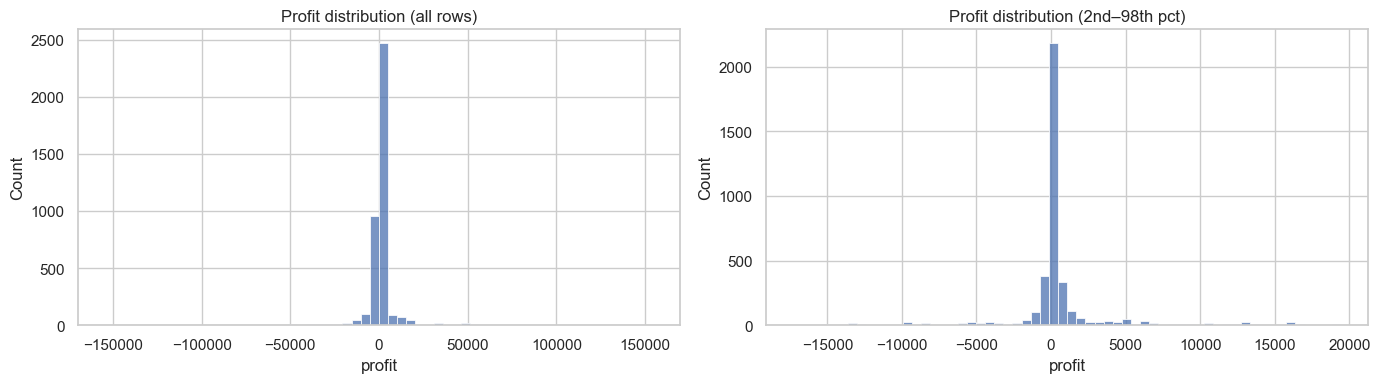

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["profit"], bins=60, ax=ax[0])
ax[0].set_title("Profit distribution (all rows)")
# Zoom into the bulk, excluding extreme tails, for readability
mask = df["profit"].between(df["profit"].quantile(0.02), df["profit"].quantile(0.98))
sns.histplot(df.loc[mask, "profit"], bins=60, ax=ax[1])
ax[1].set_title("Profit distribution (2nd–98th pct)")
plt.tight_layout()

## 6. Revenue vs. expenses

In [12]:
by_type = df.groupby("ledger_type")["profit"].agg(["count","sum","mean"]).round(2)
by_type

,count,sum,mean
ledger_type,,,
expenses,789,-1354321.02,-1716.5
revenue,3135,2887652.89,921.1


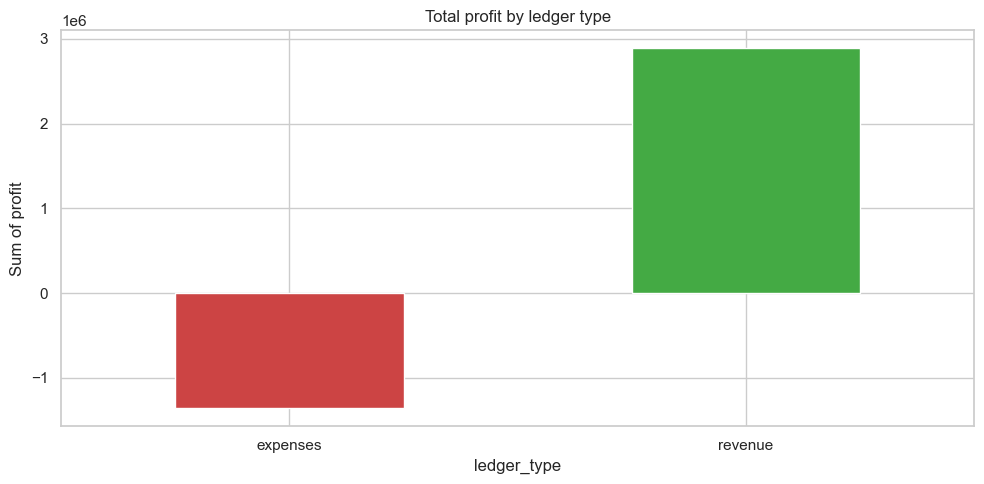

In [13]:
ax = by_type["sum"].plot(kind="bar", color=["#c44","#4a4"])
ax.set_title("Total profit by ledger type")
ax.set_ylabel("Sum of profit")
plt.xticks(rotation=0)
plt.tight_layout()

## 7. Profit over time

In [14]:
# month is like '2024-M01' -> build a sortable period
tmp = df.copy()
tmp["period"] = tmp["month"].str.replace("M", "", regex=False)  # '2024-01'
tmp["period"] = pd.to_datetime(tmp["period"], format="%Y-%m")
monthly = tmp.groupby("period")["profit"].sum().sort_index()
monthly

period
2024-01-01     88696.59
2024-02-01     83045.11
2024-03-01     90567.37
2024-04-01    102512.56
2024-05-01    110133.46
2024-06-01    105246.74
2024-07-01    117940.50
2024-08-01     97348.57
2024-09-01     97075.78
2024-10-01    100546.75
2024-11-01    100558.45
2024-12-01     77849.67
2025-01-01    120340.23
2025-02-01    125476.48
2025-03-01    115993.61
Name: profit, dtype: float64

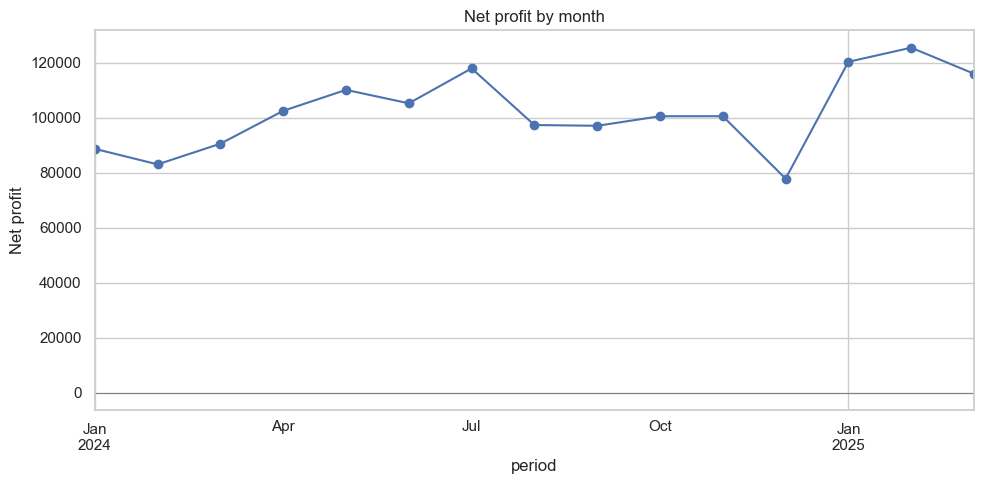

In [15]:
ax = monthly.plot(marker="o")
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Net profit by month")
ax.set_ylabel("Net profit")
plt.tight_layout()

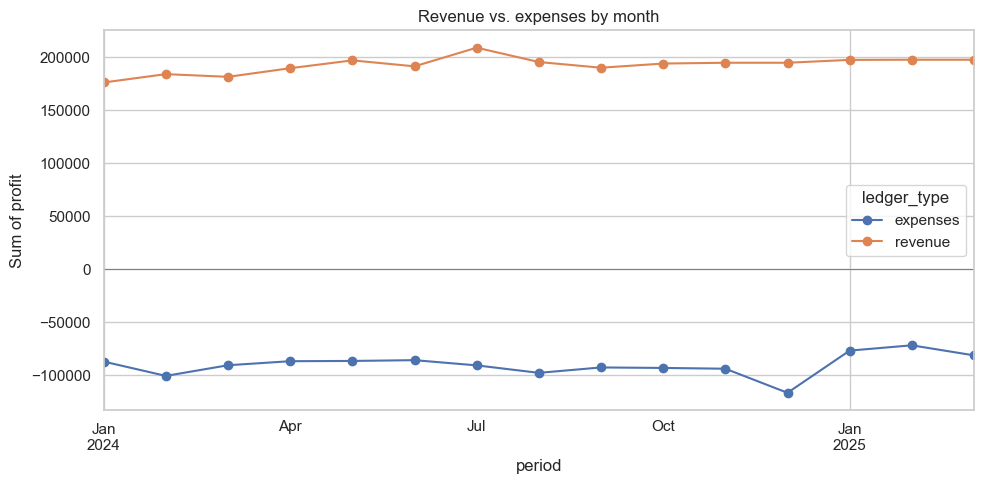

In [16]:
# Revenue vs expenses per month
piv = (tmp.groupby(["period","ledger_type"])["profit"].sum()
          .unstack("ledger_type"))
ax = piv.plot(marker="o")
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Revenue vs. expenses by month")
ax.set_ylabel("Sum of profit")
plt.tight_layout()

## 8. By property

In [17]:
by_prop = (df.groupby("property_name")["profit"]
             .agg(["count","sum","mean"]).round(2)
             .sort_values("sum", ascending=False))
by_prop

,count,sum,mean
property_name,,,
Building 120,246,850567.42,3457.59
Building 160,482,713065.13,1479.39
Building 140,841,526658.85,626.23
Building 180,324,384900.03,1187.96
Building 17,1450,352566.81,243.15


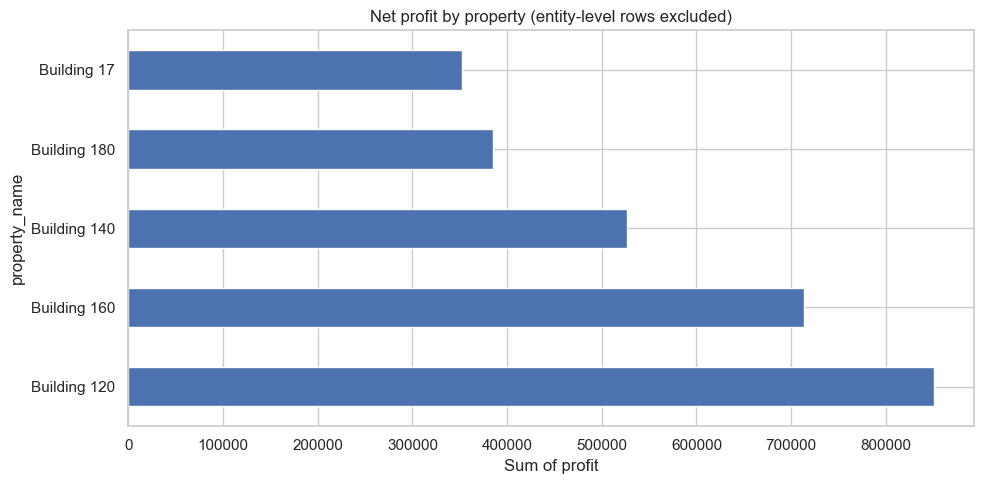

In [18]:
ax = by_prop["sum"].plot(kind="barh")
ax.set_title("Net profit by property (entity-level rows excluded)")
ax.set_xlabel("Sum of profit")
plt.tight_layout()

## 9. By tenant

In [19]:
by_tenant = (df.groupby("tenant_name")["profit"]
               .agg(["count","sum","mean"]).round(2)
               .sort_values("sum", ascending=False))
by_tenant

,count,sum,mean
tenant_name,,,
Tenant 7,191,880512.18,4610.01
Tenant 14,297,391490.29,1318.15
Tenant 11,148,292531.00,1976.56
Tenant 13,115,274344.48,2385.60
Tenant 3,375,204788.42,546.10
Tenant 12,479,166887.76,348.41
Tenant 15,193,153179.91,793.68
Tenant 16,139,115150.16,828.42
Tenant 18,104,91925.71,883.90


## 10. By ledger group & category

In [20]:
by_group = (df.groupby(["ledger_type","ledger_group"])["profit"]
              .sum().round(2)
              .sort_values())
by_group

ledger_type  ledger_group        
expenses     general_expenses        -782154.21
             management_fees         -471587.49
revenue      sales_discounts         -185101.75
expenses     taxes_and_insurances    -100579.32
revenue      rental_income           3072754.64
Name: profit, dtype: float64

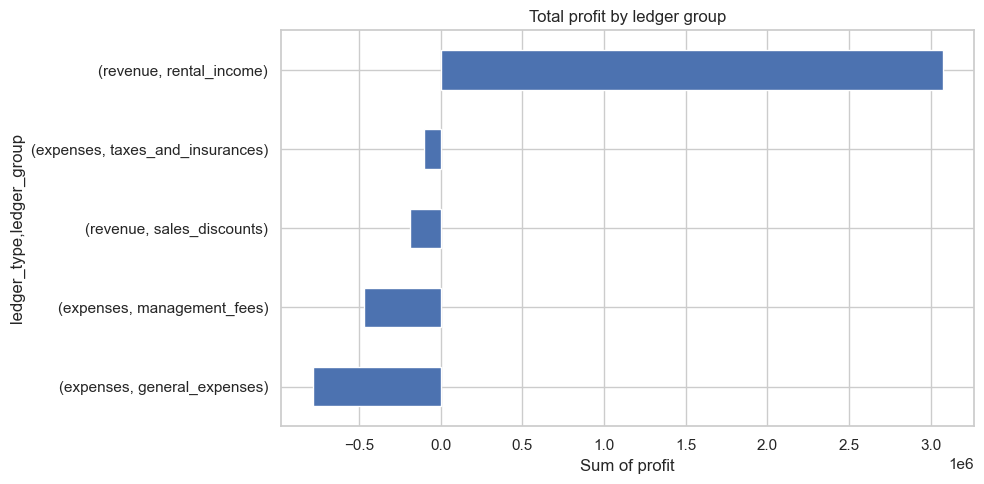

In [21]:
ax = by_group.plot(kind="barh")
ax.set_title("Total profit by ledger group")
ax.set_xlabel("Sum of profit")
plt.tight_layout()

In [22]:
# Top expense and revenue categories
top_exp = (df[df.ledger_type=="expenses"]
             .groupby("ledger_category")["profit"].sum().sort_values().head(10))
top_rev = (df[df.ledger_type=="revenue"]
             .groupby("ledger_category")["profit"].sum().sort_values(ascending=False).head(10))
print("Top expense categories:\n", top_exp, "\n")
print("Top revenue categories:\n", top_rev)

Top expense categories:
 ledger_category
interest_mortgage          -668593.43
success_fees               -180000.00
asset_management_fees      -146250.00
property_management_fees   -121916.49
real_estate_taxes           -62556.65
insurance_in_general        -38022.67
expense_return              -28196.48
research_and_information    -23778.76
non_reclaimable_sc          -20215.93
directors_fee               -16500.00
Name: profit, dtype: float64 

Top revenue categories:
 ledger_category
revenue_rent_taxed          2401204.99
proceeds_rent_untaxed        367797.38
proceeds_parking_taxed       267560.26
proceeds_parking_untaxed      20245.13
vat_compensation              15946.88
rent_discount_untaxed        -19731.87
rent_discount_taxed         -165369.88
Name: profit, dtype: float64


## 11. Summary of findings

- **Scope:** single entity (PropCo), 5 properties, 18 tenants, 29 ledger categories, monthly data 2024-M01 → 2025-M03.
- **Structure:** `property_name`/`tenant_name` are null on entity-level lines (bank charges, fees, etc.) — expected, not missing data.
- **Profit:** heavy-tailed and near-symmetric; revenue lines positive, expense lines negative.
- **Next steps for the chatbot:** these breakdowns (by property, tenant, category, month) are exactly the kinds of questions an asset-management agent should answer 
 they map naturally onto tools/queries over this ledger.